# Selected lncRNA Validation

Per-gene analysis of 6 hand-picked lncRNAs (MALAT1, NEAT1, XIST, H19, XACT, KCNQ1OT1)
projected from human (hg38) to mouse (mm39).

- Do predicted query islands overlap known mouse GENCODE exons?
- What are the MMD scores per island?
- Per-gene breakdown with plots.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pyrion.io.bed import read_bed12_file
from pyrion.ops.interval_ops import intersect_intervals, merge_intervals
from pyrion.core.intervals import GenomicInterval

In [2]:
SELECTED_GENES = {
    "ENSG00000251562": "MALAT1",
    "ENSG00000245532": "NEAT1",
    "ENSG00000229807": "XIST",
    "ENSG00000130600": "H19",
    "ENSG00000241743": "XACT",
    "ENSG00000269821": "KCNQ1OT1",
}
SELECTED_IDS = {f"U_{gid}" for gid in SELECTED_GENES}
ID_TO_NAME = {f"U_{gid}": name for gid, name in SELECTED_GENES.items()}

PIPELINE_DIR = Path("../quick_test")
ANNOTATION_DIR = Path("../input_data/mm39_annotation_validation")

results = pd.read_csv(PIPELINE_DIR / "island_alignment_results.tsv", sep="\t")
query_bed = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "lncRNA_islands.bed"))
ref_bed = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "reference_islands.bed"))
query_islands_all_bed = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "query_islands.bed"))
annotation = read_bed12_file(str(ANNOTATION_DIR / "mm39_quick_test_transcripts.bed"))

sel = results[results["gene_id"].isin(SELECTED_IDS)].copy()
sel["gene_name"] = sel["gene_id"].map(ID_TO_NAME)

print(f"Island results: {len(results)} total, {len(sel)} for selected genes")
print(f"Query BED (aligned): {len(query_bed)} entries")
print(f"Reference islands (all): {len(ref_bed)} entries")
print(f"Query islands (all): {len(query_islands_all_bed)} entries")
print(f"Annotation: {len(annotation):,} transcripts")
print(f"\nSelected genes: {', '.join(ID_TO_NAME.values())}")

Island results: 210 total, 121 for selected genes
Query BED (aligned): 58 entries
Reference islands (all): 659 entries
Query islands (all): 454 entries
Annotation: 35,597 transcripts

Selected genes: MALAT1, NEAT1, XIST, H19, XACT, KCNQ1OT1


## Overview

In [3]:
overview_rows = []
for gid, name in sorted(ID_TO_NAME.items(), key=lambda x: x[1]):
    g = sel[sel["gene_id"] == gid]
    q_transcript = query_bed.get_by_id(f"{gid}_aligned")
    q_span = f"{q_transcript.chrom}:{q_transcript.start}-{q_transcript.end}" if q_transcript else "N/A"
    q_bp = int(np.sum(q_transcript.blocks[:, 1] - q_transcript.blocks[:, 0])) if q_transcript else 0
    overview_rows.append({
        "gene": name,
        "gene_id": gid,
        "query_location": q_span,
        "n_islands": len(g),
        "n_anchor": (g["type"] == "anchor").sum(),
        "n_fill": (g["type"] == "fill").sum(),
        "query_span_bp": q_transcript.end - q_transcript.start if q_transcript else 0,
        "query_exonic_bp": q_bp,
        "median_mmd": g["diag_mmd"].median(),
        "mean_mmd": g["diag_mmd"].mean(),
    })

overview = pd.DataFrame(overview_rows)
print(overview[["gene", "query_location", "n_islands", "n_anchor", "n_fill",
                 "query_exonic_bp", "median_mmd"]].to_string(index=False))

    gene           query_location  n_islands  n_anchor  n_fill  query_exonic_bp  median_mmd
     H19 chr7:142131456-142131824          2         2       0              232     0.06515
KCNQ1OT1 chr7:142804883-142846416         58        58       0             7311     0.03570
  MALAT1    chr19:5844733-5850277          4         4       0              508     0.00000
   NEAT1    chr19:5874526-5895263         25        25       0             3694     0.05180
    XACT chrX:145009907-145190883         28        28       0             3260     0.03930
    XIST chrX:102510228-102524041          4         4       0              432     0.04550


## Overlap with mouse GENCODE annotation

In [4]:
overlap_rows = []
for gid, name in sorted(ID_TO_NAME.items(), key=lambda x: x[1]):
    q_t = query_bed.get_by_id(f"{gid}_aligned")
    if q_t is None:
        continue

    q_interval = GenomicInterval(q_t.chrom, q_t.start, q_t.end)
    hits = annotation.get_transcripts_in_interval(q_interval)

    best_bp = 0
    best_pct = 0.0
    best_tid = None
    exon_hit_ids = []
    q_exonic_bp = int(np.sum(q_t.blocks[:, 1] - q_t.blocks[:, 0]))

    for t in hits:
        isect = intersect_intervals(q_t.blocks, t.blocks)
        if len(isect) > 0:
            bp = int(np.sum(isect[:, 1] - isect[:, 0]))
            exon_hit_ids.append((t.id, bp))
            if bp > best_bp:
                best_bp = bp
                best_pct = bp / q_exonic_bp * 100
                best_tid = t.id

    overlap_rows.append({
        "gene": name,
        "query_chrom": q_t.chrom,
        "query_exonic_bp": q_exonic_bp,
        "n_transcripts_in_span": len(hits),
        "n_exon_overlapping": len(exon_hit_ids),
        "best_overlap_bp": best_bp,
        "best_overlap_pct": best_pct,
        "best_transcript": best_tid,
        "all_exon_hits": exon_hit_ids,
    })

overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df[["gene", "query_exonic_bp", "n_transcripts_in_span",
                    "n_exon_overlapping", "best_overlap_bp", "best_overlap_pct",
                    "best_transcript"]].to_string(index=False))

print("\n--- Detailed exon-level hits ---")
for _, row in overlap_df.iterrows():
    if row["all_exon_hits"]:
        print(f"\n{row['gene']}:")
        for tid, bp in sorted(row["all_exon_hits"], key=lambda x: -x[1])[:5]:
            print(f"  {tid}: {bp} bp overlap")
    else:
        print(f"\n{row['gene']}: no exon overlap")

    gene  query_exonic_bp  n_transcripts_in_span  n_exon_overlapping  best_overlap_bp  best_overlap_pct       best_transcript
     H19              232                     22                  19              232        100.000000 ENSMUST00000136359.10
KCNQ1OT1             7311                     13                   6             7311        100.000000  ENSMUST00000185789.3
  MALAT1              508                     12                   5              248         48.818898  ENSMUST00000172812.5
   NEAT1             3694                     28                  27             3514         95.127233  ENSMUST00000173672.4
    XACT             3260                      2                   0                0          0.000000                   NaN
    XIST              432                      9                   2              343         79.398148  ENSMUST00000127786.4

--- Detailed exon-level hits ---

H19:
  ENSMUST00000136359.10: 232 bp overlap
  ENSMUST00000247195.2: 232 bp overlap

## MMD score distributions

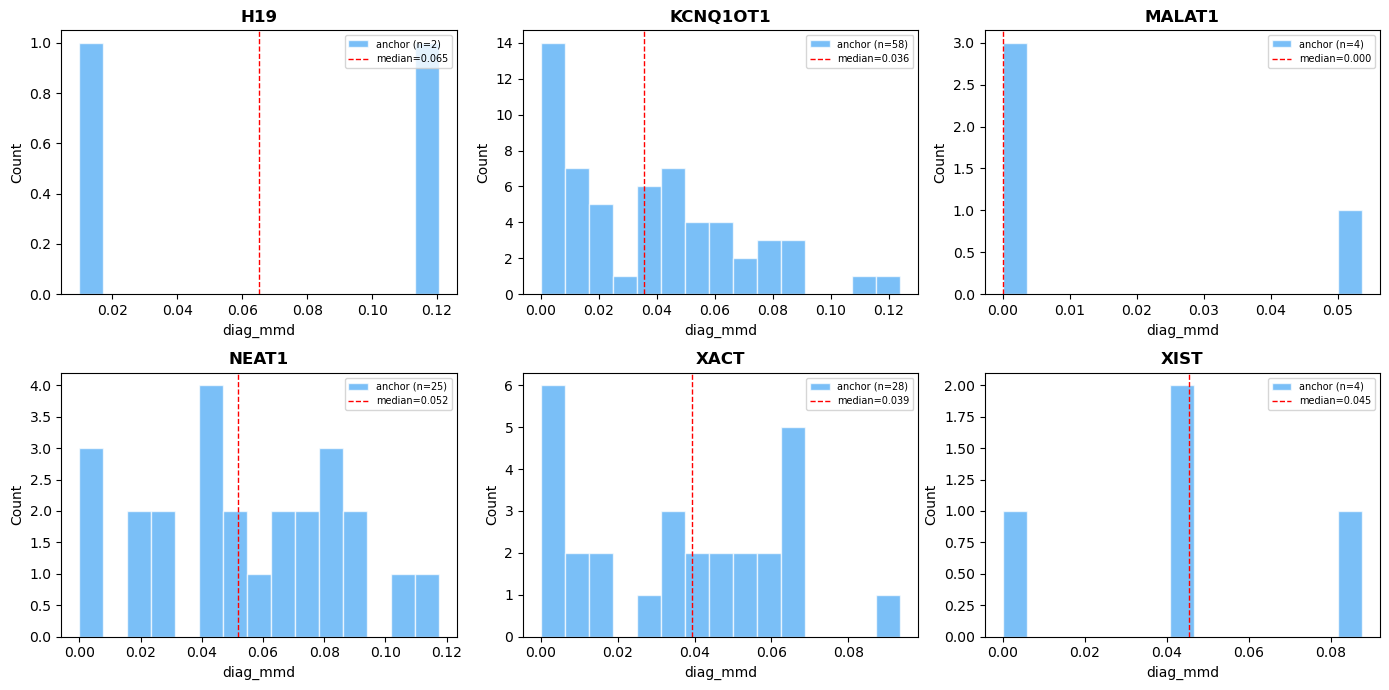

In [5]:
gene_names_sorted = sorted(ID_TO_NAME.values())
n_genes = len(gene_names_sorted)
name_to_id = {v: k for k, v in ID_TO_NAME.items()}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, name in enumerate(gene_names_sorted):
    ax = axes[i]
    gid = name_to_id[name]
    g = sel[sel["gene_id"] == gid]

    anchors = g[g["type"] == "anchor"]["diag_mmd"]
    fills = g[g["type"] == "fill"]["diag_mmd"]

    if len(anchors) > 0:
        ax.hist(anchors, bins=15, alpha=0.7, color="#42A5F5", label=f"anchor (n={len(anchors)})",
                edgecolor="white")
    if len(fills) > 0:
        ax.hist(fills, bins=15, alpha=0.7, color="#FFA726", label=f"fill (n={len(fills)})",
                edgecolor="white")

    ax.axvline(g["diag_mmd"].median(), color="red", linestyle="--", linewidth=1,
               label=f"median={g['diag_mmd'].median():.3f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("diag_mmd")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Per-gene detail

For each gene, two-panel view:
- **Reference genome (top)**: all detected reference islands (gray) and aligned subset (colored by type), with MMD annotations.
- **Query genome (bottom)**: aligned query blocks, all detected query islands, and overlapping GENCODE exons.


H19 (ENSG00000130600)
Query: chr7:142131456-142131824 (368 bp span)
Aligned islands: 2 (2 anchor, 0 fill)
Ref islands (all): 5, Query islands (all): 8
Transcripts in span: 22

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q5 anchor 142131432 142131600    168 0.1205     168         0           0
    Q6 anchor 142131704 142131824    120 0.0098     120         0           0


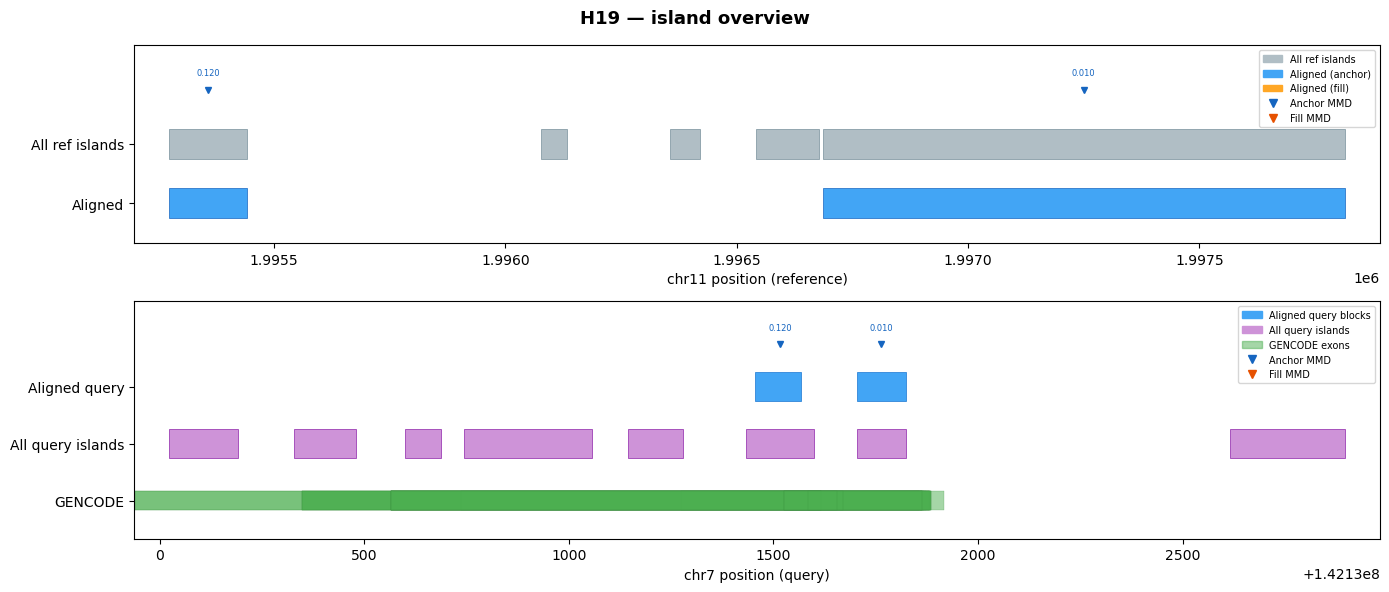


KCNQ1OT1 (ENSG00000269821)
Query: chr7:142804883-142846416 (41,533 bp span)
Aligned islands: 58 (58 anchor, 0 fill)
Ref islands (all): 121, Query islands (all): 88
Transcripts in span: 13

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q0 anchor 142804827 142804995    168 0.1079     168         0           0
    Q1 anchor 142805019 142805267    248 0.0599     248         0           0
    Q9 anchor 142808683 142808883    200 0.1240     200         0           0
   Q10 anchor 142808891 142809043    152 0.0000     152         0           0
   Q11 anchor 142809195 142809347    152 0.0505     152         0           0
   Q13 anchor 142814581 142814829    248 0.0840     248         0           0
   Q14 anchor 142814949 142815357    408 0.0575     408         0           0
   Q15 anchor 142815184 142815352    168 0.0143     168         0           0
   Q16 anchor 142815568 142815848    280 0.0249     280         0           0
   Q17 anchor 142815573 142815

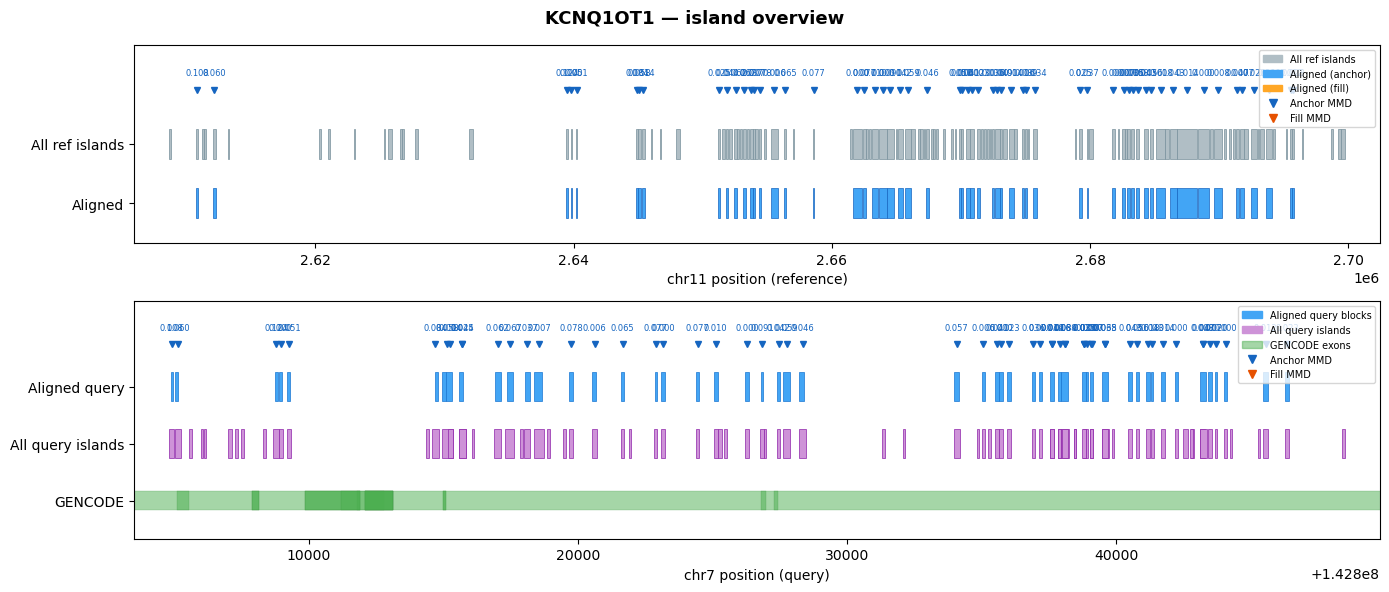


MALAT1 (ENSG00000251562)
Query: chr19:5844733-5850277 (5,544 bp span)
Aligned islands: 4 (4 anchor, 0 fill)
Ref islands (all): 11, Query islands (all): 10
Transcripts in span: 12

island   type  q_start   q_end  q_len    mmd  exonic  intronic  intergenic
    Q2 anchor  5844733 5844885    152 0.0000       0         0         152
    Q4 anchor  5845149 5845365    216 0.0536       0         0         216
    Q6 anchor  5847650 5847754    104 0.0000     104         0           0
    Q8 anchor  5850125 5850277    152 0.0000     152         0           0


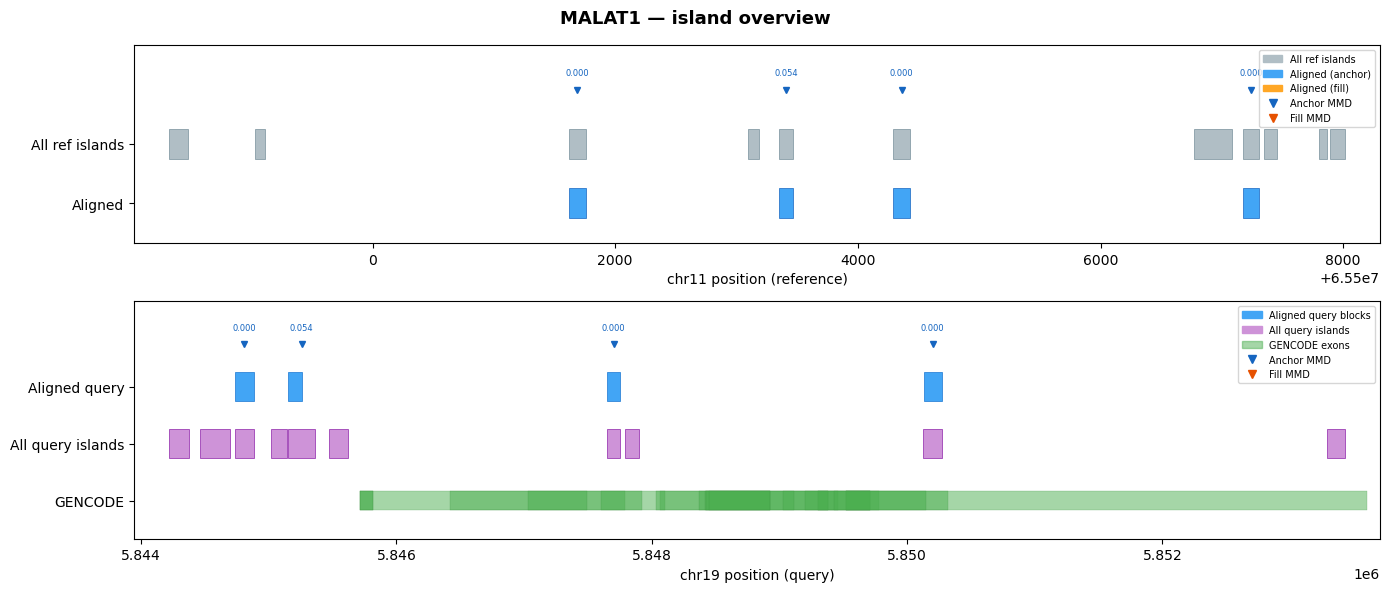


NEAT1 (ENSG00000245532)
Query: chr19:5874526-5895263 (20,737 bp span)
Aligned islands: 25 (25 anchor, 0 fill)
Ref islands (all): 35, Query islands (all): 43
Transcripts in span: 28

island   type  q_start   q_end  q_len    mmd  exonic  intronic  intergenic
    Q0 anchor  5874490 5874706    216 0.0462      27         0         189
    Q1 anchor  5874778 5875106    328 0.0202     328         0           0
    Q2 anchor  5875242 5875362    120 0.0433     120         0           0
    Q3 anchor  5875402 5875714    312 0.0000     312         0           0
    Q4 anchor  5875978 5876450    472 0.0933     472         0           0
    Q5 anchor  5876012 5876324    312 0.0719     312         0           0
    Q9 anchor  5876876 5877012    136 0.0860     136         0           0
   Q12 anchor  5877372 5877508    136 0.0051     136         0           0
   Q13 anchor  5877708 5877828    120 0.0816     120         0           0
   Q14 anchor  5877852 5877940     88 0.0312      88         0     

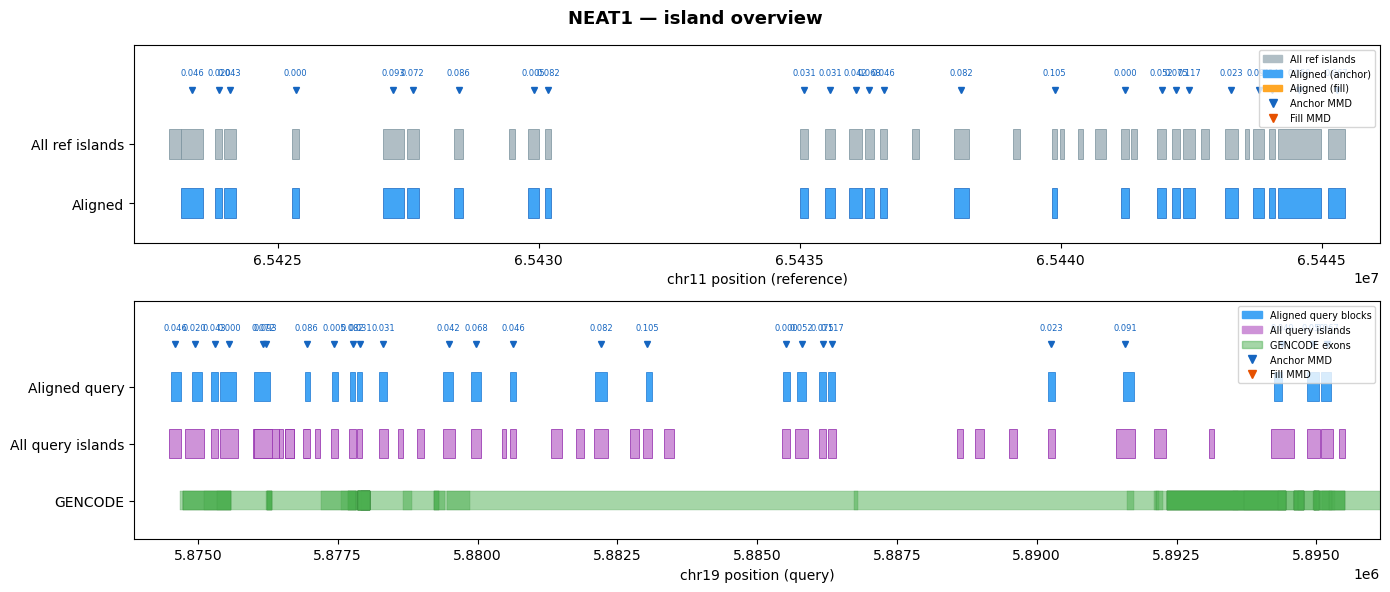


XACT (ENSG00000241743)
Query: chrX:145009907-145190883 (180,976 bp span)
Aligned islands: 28 (28 anchor, 0 fill)
Ref islands (all): 211, Query islands (all): 45
Transcripts in span: 2

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q1 anchor 145009907 145010251    344 0.0000       0         0         344
    Q2 anchor 145010483 145010619    136 0.0672       0         0         136
    Q3 anchor 145011795 145011915    120 0.0683       0         0         120
    Q4 anchor 145014871 145014975    104 0.0654       0         0         104
    Q5 anchor 145016878 145017014    136 0.0581       0         0         136
    Q6 anchor 145031535 145031655    120 0.0519       0         0         120
   Q10 anchor 145043067 145043187    120 0.0153       0         0         120
   Q12 anchor 145046826 145046946    120 0.0000       0         0         120
   Q14 anchor 145049578 145049714    136 0.0674       0         0         136
   Q15 anchor 145055191 145055343 

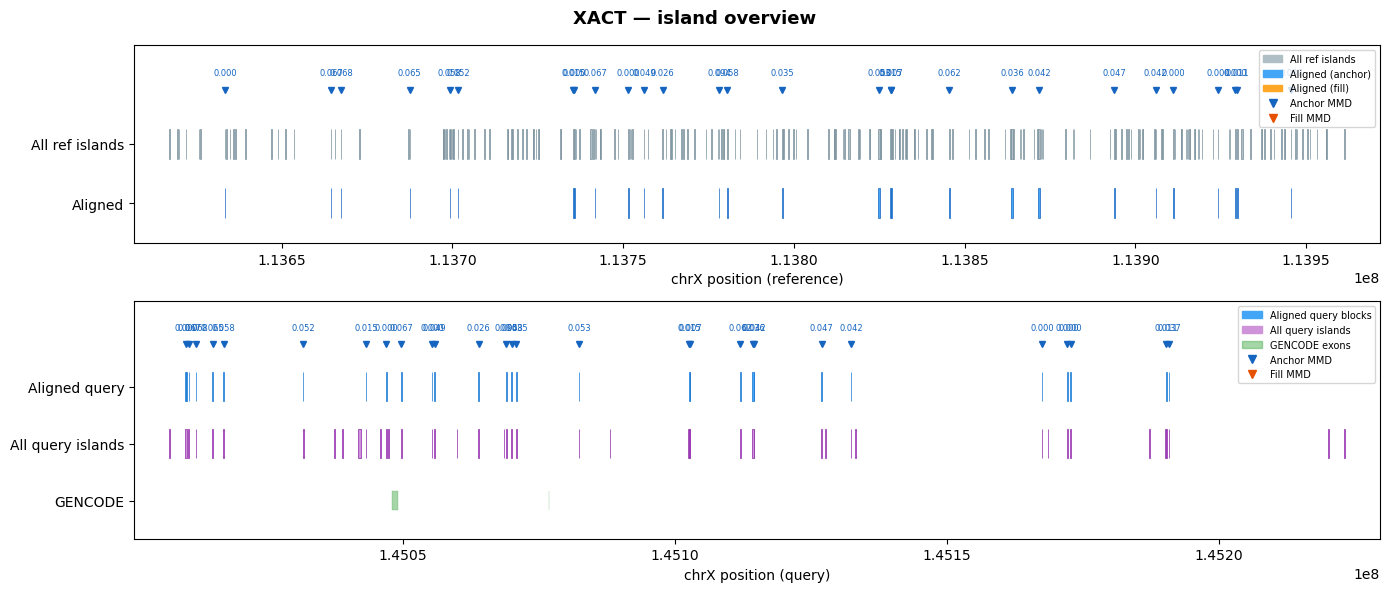


XIST (ENSG00000229807)
Query: chrX:102510228-102524041 (13,813 bp span)
Aligned islands: 4 (4 anchor, 0 fill)
Ref islands (all): 13, Query islands (all): 4
Transcripts in span: 9

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q0 anchor 102510228 102510348    120 0.0000     120         0           0
    Q1 anchor 102512326 102512430    104 0.0876       7        97           0
    Q2 anchor 102519243 102519331     88 0.0450      88         0           0
    Q3 anchor 102523773 102524053    280 0.0460     280         0           0


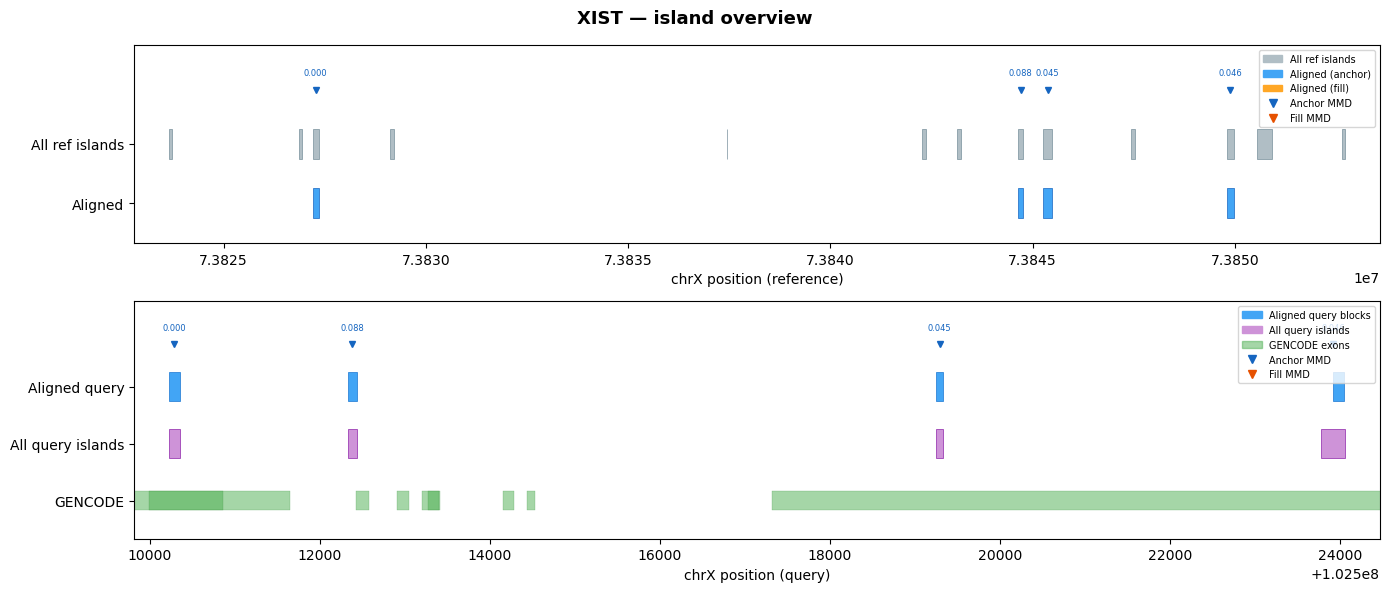

In [6]:
for name in gene_names_sorted:
    gid = name_to_id[name]
    g = sel[sel["gene_id"] == gid].sort_values("query_start")
    q_t = query_bed.get_by_id(f"{gid}_aligned")
    if q_t is None:
        print(f"\n{'='*60}\n{name} ({gid}): no query prediction\n")
        continue

    q_interval = GenomicInterval(q_t.chrom, q_t.start, q_t.end)
    hits = annotation.get_transcripts_in_interval(q_interval)

    ref_islands_gene = [t for t in ref_bed.transcripts if t.id.startswith(f"{gid}_island")]
    query_islands_gene = [
        t for t in query_islands_all_bed.transcripts
        if t.id.startswith(gid) and len(t.id) > len(gid) and t.id[len(gid)] in ("_", ".")
    ]

    print(f"\n{'='*60}")
    print(f"{name} ({gid.replace('U_', '')})")
    print(f"Query: {q_t.chrom}:{q_t.start}-{q_t.end} ({q_t.end - q_t.start:,} bp span)")
    print(f"Aligned islands: {len(g)} ({(g['type']=='anchor').sum()} anchor, {(g['type']=='fill').sum()} fill)")
    print(f"Ref islands (all): {len(ref_islands_gene)}, Query islands (all): {len(query_islands_gene)}")
    print(f"Transcripts in span: {len(hits)}")

    # merge all GENCODE exon blocks and transcript spans (avoid double-counting)
    all_exon_blocks = [t.blocks for t in hits]
    all_spans = np.array([[t.start, t.end] for t in hits]) if len(hits) > 0 else np.empty((0, 2), dtype=int)

    if len(all_exon_blocks) > 0:
        merged_exons = merge_intervals(np.vstack(all_exon_blocks))
        merged_spans = merge_intervals(all_spans)
    else:
        merged_exons = np.empty((0, 2), dtype=int)
        merged_spans = np.empty((0, 2), dtype=int)

    # per-island table with exonic / intronic / intergenic breakdown
    island_rows = []
    for _, isl in g.iterrows():
        isl_arr = np.array([[isl["query_start"], isl["query_end"]]])
        isl_len = isl["query_len"]

        exon_isect = intersect_intervals(isl_arr, merged_exons)
        exonic_bp = int(np.sum(exon_isect[:, 1] - exon_isect[:, 0])) if len(exon_isect) > 0 else 0

        span_isect = intersect_intervals(isl_arr, merged_spans)
        in_transcript_bp = int(np.sum(span_isect[:, 1] - span_isect[:, 0])) if len(span_isect) > 0 else 0

        intronic_bp = in_transcript_bp - exonic_bp
        intergenic_bp = isl_len - in_transcript_bp

        island_rows.append({
            "island": isl["query_island"],
            "type": isl["type"],
            "q_start": isl["query_start"],
            "q_end": isl["query_end"],
            "q_len": isl_len,
            "mmd": f"{isl['diag_mmd']:.4f}",
            "exonic": exonic_bp,
            "intronic": intronic_bp,
            "intergenic": intergenic_bp,
        })
    isl_df = pd.DataFrame(island_rows)
    print(f"\n{isl_df.to_string(index=False)}")

    # === Two-panel plot: reference genome (top) + query genome (bottom) ===
    fig, (ax_ref, ax_query) = plt.subplots(
        2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [1, 1.2]}
    )
    fig.suptitle(f"{name} — island overview", fontweight="bold", fontsize=13)

    # --- Top panel: Reference genome ---
    for t in ref_islands_gene:
        ax_ref.barh(1.0, t.end - t.start, left=t.start, height=0.3,
                    color="#B0BEC5", edgecolor="#78909C", linewidth=0.5)

    for _, isl in g.iterrows():
        is_anchor = isl["type"] == "anchor"
        fill_c = "#42A5F5" if is_anchor else "#FFA726"
        edge_c = "#1565C0" if is_anchor else "#E65100"
        ax_ref.barh(0.4, isl["ref_end"] - isl["ref_start"], left=isl["ref_start"],
                    height=0.3, color=fill_c, edgecolor=edge_c, linewidth=0.5)
        mid = (isl["ref_start"] + isl["ref_end"]) / 2
        ax_ref.plot(mid, 1.55, marker="v", color=edge_c, markersize=5)
        ax_ref.text(mid, 1.7, f'{isl["diag_mmd"]:.3f}', ha="center", fontsize=6, color=edge_c)

    ref_chrom = g["ref_chrom"].iloc[0] if len(g) > 0 else (
        ref_islands_gene[0].chrom if ref_islands_gene else "?")
    all_ref_s = [t.start for t in ref_islands_gene] + g["ref_start"].tolist()
    all_ref_e = [t.end for t in ref_islands_gene] + g["ref_end"].tolist()
    rs, re = (min(all_ref_s), max(all_ref_e)) if all_ref_s else (0, 1)
    rm = (re - rs) * 0.03
    ax_ref.set_xlim(rs - rm, re + rm)
    ax_ref.set_ylim(0, 2.0)
    ax_ref.set_yticks([0.4, 1.0])
    ax_ref.set_yticklabels(["Aligned", "All ref islands"])
    ax_ref.set_xlabel(f"{ref_chrom} position (reference)")
    ax_ref.legend(handles=[
        mpatches.Patch(color="#B0BEC5", label="All ref islands"),
        mpatches.Patch(color="#42A5F5", label="Aligned (anchor)"),
        mpatches.Patch(color="#FFA726", label="Aligned (fill)"),
        plt.Line2D([0], [0], marker="v", color="#1565C0", linestyle="None", label="Anchor MMD"),
        plt.Line2D([0], [0], marker="v", color="#E65100", linestyle="None", label="Fill MMD"),
    ], fontsize=7, loc="upper right")

    # --- Bottom panel: Query genome ---
    span_start, span_end = q_t.start, q_t.end

    for block_s, block_e in q_t.blocks:
        ax_query.barh(1.6, block_e - block_s, left=block_s, height=0.3,
                      color="#42A5F5", edgecolor="#1976D2", linewidth=0.5)

    for _, isl in g.iterrows():
        mid = (isl["query_start"] + isl["query_end"]) / 2
        is_anchor = isl["type"] == "anchor"
        mc = "#1565C0" if is_anchor else "#E65100"
        ax_query.plot(mid, 2.05, marker="v", color=mc, markersize=5)
        ax_query.text(mid, 2.2, f'{isl["diag_mmd"]:.3f}', ha="center", fontsize=6, color=mc)

    for t_q in query_islands_gene:
        ax_query.barh(1.0, t_q.end - t_q.start, left=t_q.start, height=0.3,
                      color="#CE93D8", edgecolor="#8E24AA", linewidth=0.5)

    for t in hits:
        for block_s, block_e in t.blocks:
            if block_e > span_start and block_s < span_end:
                ax_query.barh(0.4, block_e - block_s, left=block_s, height=0.2,
                              color="#4CAF50", alpha=0.5, edgecolor="#388E3C", linewidth=0.3)

    all_q_s = [t_q.start for t_q in query_islands_gene] + [span_start]
    all_q_e = [t_q.end for t_q in query_islands_gene] + [span_end]
    qs, qe = min(all_q_s), max(all_q_e)
    qm = (qe - qs) * 0.03
    ax_query.set_xlim(qs - qm, qe + qm)
    ax_query.set_ylim(0, 2.5)
    ax_query.set_yticks([0.4, 1.0, 1.6])
    ax_query.set_yticklabels(["GENCODE", "All query islands", "Aligned query"])
    ax_query.set_xlabel(f"{q_t.chrom} position (query)")
    ax_query.legend(handles=[
        mpatches.Patch(color="#42A5F5", label="Aligned query blocks"),
        mpatches.Patch(color="#CE93D8", label="All query islands"),
        mpatches.Patch(color="#4CAF50", alpha=0.5, label="GENCODE exons"),
        plt.Line2D([0], [0], marker="v", color="#1565C0", linestyle="None", label="Anchor MMD"),
        plt.Line2D([0], [0], marker="v", color="#E65100", linestyle="None", label="Fill MMD"),
    ], fontsize=7, loc="upper right")

    plt.tight_layout()
    plt.show()